### sys.executable > 확인 역할 노트북이 어느 파이썬에 있는지 설치 위치를 확인함 사실 이미 가상환경이 하나 더 있어서 위치가 처음에 조금 헷갈렸었음

### 퀵 스타터 추가 

In [7]:
# ===== Day 2 Quick Start — 이 셀 하나로 재가동 =====
import os, subprocess, time, requests

# 1. 작업 위치 고정
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print("📁", os.getcwd())

BASE = "http://127.0.0.1:8000"

# 2. 서버 살아있나 먼저 확인 (이미 떠 있으면 재기동 불필요)
def server_alive():
    try:
        return requests.get(f"{BASE}/models?limit=1", timeout=2).status_code == 200
    except requests.exceptions.RequestException:
        return False

if server_alive():
    print("✅ 서버 이미 가동 중 — 바로 작업 시작")
else:
    # 3. 새 터미널 창을 열어 서버 기동 (venv 파이썬으로 직접 실행 → activate 불필요)
    print("🚀 서버 기동 중...")
    subprocess.Popen(
        'start "uvicorn-server" cmd /k ".venv\\Scripts\\python.exe -m uvicorn app.main_params:app --host 127.0.0.1 --port 8000"',
        shell=True,
    )
    # 4. 뜰 때까지 대기 후 확인
    for _ in range(20):
        time.sleep(0.5)
        if server_alive():
            print("✅ 서버 가동 + 응답 확인 완료")
            break
    else:
        print("❌ 안 떴음 — 새로 열린 터미널 창의 에러 메시지 확인 (포트 점유면: netstat -ano | findstr :8000)")

📁 c:\Users\akals\Downloads\model-serving-course
🚀 서버 기동 중...
✅ 서버 가동 + 응답 확인 완료


In [5]:
import sys
print(sys.executable)

import torch
print(torch.__version__)

c:\Users\akals\Downloads\model-serving-course\.venv\Scripts\python.exe
2.12.0+cpu


## 모델정의
모델 구조를 간단히 정의, 구현. 
은닉층 하나짜리인 간단한 모델을 구현해서 파이프라인을 검증하기 위한 재료로 씀
파이프라인 검증이니 모델을 복잡하게 하면 변인 통제가 제대로 되지 않지 않을까 싶음 


In [8]:
import torch
import torch.nn as nn

class SimpleClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.fc(x)

## 데이터 로드&학습


In [17]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_data = datasets.MNIST(
    root = "../data", train=True, download=True,
    transform=transforms.ToTensor()
)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

model = SimpleClassifier()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

model.train()
for epoch in range(1):
    for x, y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
    print(f"epoch {epoch}: loss {loss.item():.4f}")

          

epoch 0: loss 0.3514


In [13]:
import os
%pip install onnxscript
os.makedirs("../models", exist_ok=True)


   ---------------------------------------- 0.0/714.8 kB ? eta -:--:--
   --------------------------------------- 714.8/714.8 kB 13.1 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [onnx_ir]
   ---------------------------------------- 0/2 [onnx_ir]
   -------------------- ------------------- 1/2 [onnxscript]
   -------------------- ------------------- 1/2 [onnxscript]
   -------------------- ------------------- 1/2 [onnxscript]
   -------------------- ------------------- 1/2 [onnxscript]
   -------------------- ------------------- 1/2 [onnxscript]
   -------------------- ------------------- 1/2 [onnxscript]
   -------------------- ------------------- 1/2 [onnxscript]
   ---------------------------------------- 2/2 [onnxscript]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 3가지 방식으로 저장 

model.eval()는 모델의 모드 전환 스위치.  안쳐도 상관은 없었지만 습관으로 만들기 위해서 추가함 
example_input는 2,3이 공유하는 재료로 가짜 입력을 실제로 모델에 흘려보내면서 연산경로를 추적함. 

torch.save를 통해 각 경로로 저장되며 
torch.save(①), ts.save(②), torch.onnx.export(③) — 담는 내용이 다르니 저장 도구도 다르다. 
①은 가중치 딕셔너리만, 
②는 걸어간 연산 경로(구조)까지, 
③은 PyTorch 밖에서도 열리도록 표준 포맷으로 번역해 내보냄.

In [19]:
model.eval()

example_input = torch.randn(1, 1, 28, 28)

#가중치 저장
torch.save(model.state_dict(), "../models/model.pth")
#구조 저장 
ts = torch.jit.trace(model, example_input)
ts.save("../models/model.pt")
#오닉스 - 프레임워크 독립
torch.onnx.export(
    model, example_input, "../models/model.onnx",
    input_names=["input"], output_names=["output"],
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}}
)

C:\Users\akals\AppData\Local\Temp\ipykernel_58856\1531014663.py:11: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `SimpleClassifier([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SimpleClassifier([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅


C:\Python313\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.12.0+cpu',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[batch_size,1,28,28]>
            ),
            outputs=(
                %"output"<FLOAT,[batch_size,10]>
            ),
            initializers=(
                %"fc.1.weight"<FLOAT,[128,784]>{TorchTensor(...)},
                %"fc.1.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"fc.3.weight"<FLOAT,[10,128]>{TorchTensor(...)},
                %"fc.3.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Parameter containing: tensor([-0.1247,  0.0674,  0.0348, -0.0030, -0.0163,  0.1166, -0.0712, -0.0242, -0.1247,  0.0300], requires_grad=True), name='fc.3.bias')},
                %"val_3"<INT64,[1]>{Tensor<INT64,[1]>(array([784]), name='val_3')}
      

In [1]:
import os
print(os.listdir("../models"))

['model.onnx', 'model.onnx.data', 'model.pt', 'model.pth']


In [2]:
print(os.getcwd())
print(os.listdir("../models"))

c:\Users\akals\Downloads\model-serving-course\.venv
['model.onnx', 'model.onnx.data', 'model.pt', 'model.pth']


In [3]:
import os
for f in sorted(os.listdir("../models")):
    print(f"{f:20s} {os.path.getsize(os.path.join('../models', f)):>10,} bytes")

model.onnx                8,213 bytes
model.onnx.data         407,040 bytes
model.pt                418,405 bytes
model.pth               409,353 bytes


### 유사배포단계? 
import onnxruntime as ort는 사실 torch.onnx와는 별개의 패키지 같아 보였음 
torch.onnx가 파이토치에서 오닉스로 변환하는 출구역할이라면 onnxruntime 는 실행하는 쪽의 독립엔진이다. 
분리 : 배포지에는 onnxruntime깔면 됨, 서버에서 코드가 그대로 돌게 됨 
다만 torch.Tensor를 그대로 박을수는 없기 때문에 numpy로 변환해야 한다. 

검증은 np.allclose로 출력을 비교하고 
호출자가 나 > 남으로 바뀌는 순간이다. 


In [13]:
import onnxruntime as ort
import numpy as np

test_input = torch.randn(4, 1, 28, 28)

# 클래스 정의로 
m1 = SimpleClassifier()
m1.load_state_dict(torch.load("../models/model.pth", weights_only=True))
m1.eval()
with torch.no_grad():
    out1 = m1(test_input)

#파일로 로드

m2 = torch.jit.load("../models/model.pt")
m2.eval()
with torch.no_grad():
    out2 = m2(test_input)

# 오닉스

sess = ort.InferenceSession("../models/model.onnx")
out3 = sess.run(None, {"input": test_input.numpy()})[0]

print("pth vs pt  :", np.allclose(out1.numpy(), out2.numpy()))
print("pth vs onnx:", np.allclose(out1.numpy(), out3, atol=1e-5))

pth vs pt  : True
pth vs onnx: True


In [14]:
def predict(model, x):
    model.eval()
    with torch.no_grad():
        return model(x).argmax(dim=1)

print(predict(m1, test_input))   # 배치 4개의 예측 클래스

tensor([7, 0, 2, 6])


In [15]:
from torchvision import datasets, transforms
test_data = datasets.MNIST(root="../data", train=False, download=True,
                           transform=transforms.ToTensor())
x, y = next(iter(torch.utils.data.DataLoader(test_data, batch_size=8)))
print("예측:", predict(m1, x).tolist())
print("정답:", y.tolist())

예측: [7, 2, 1, 0, 4, 1, 4, 9]
정답: [7, 2, 1, 0, 4, 1, 4, 9]


### 2일차 - FastAPI 기초와 데이터 처리 
노트북 속 모델을 HTTP로 부를수 있는  API로 감싼다. 

In [13]:
# 셀1
import os 
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(os.getcwd())   # ...\model-serving-course 확인

c:\Users\akals\Downloads\model-serving-course


### 작업위치를 고정
어제한 작업이 계속 파일을 읽어오지 못해서 작업위치를 아예 고정하기로 함
주피터는 이미 이벤트 루프가 돌아서 uvicorn을 그냥 못 띄운다, 그래서 별도 스레드

In [14]:
# [셀 1] 작업 위치를 프로젝트 루트로 고정
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(os.getcwd())   # ...\model-serving-course 확인

# [셀 2] 어제 가중치가 오늘 구조와 맞는지 검증
import torch
sd = torch.load("models/model.pth", weights_only=True)
for k, v in sd.items():
    print(k, tuple(v.shape))

c:\Users\akals\Downloads\model-serving-course
fc.1.weight (128, 784)
fc.1.bias (128,)
fc.3.weight (10, 128)
fc.3.bias (10,)


### Fast API 서버의 최소단위 > FastAPI()객체 하나, 데코레이터 하나, 함수 하나, dict리턴, 기본 구조라 봐야할듯 
@app.get("/health") > 데코레이터 하나가 메서드+경로 두가지를 동시에 선언함 
dict 을 그냥 리턴하면 JSON변환은 FastAPI가 한다는 것 


### 오류1 

%%writefile를 IPython이 인식하지 못함 
첫줄 위치 교정을 시도해도 여전히 not found가 나왔고 
%lsmagic으로 확인했을 때 %%writefile이 존재하는건 확인함
새 셀에 다시 쳤을 때 에러가 바뀌었고 os.makedirs('app')으로 성공함 

%%명령은 반드시 셀의 첫 줄에 있어야함. 
근데 나는 주석으로 #셀4라고 가장 첫칸에 달아놨기 때문에 오류가 생겼던것 같음



In [21]:
#셀 4 

%%writefile app/main_basic.py

from fastapi import FastAPI

app = FastAPI(title="My First ML API")

@app.get("/health")
def health_check():
    return {"status": "healthy"}

UsageError: Line magic function `%%writefile` not found.


In [22]:
%lsmagic

Available line magics:
%alias  %alias_magic  %autoawait  %autocall  %automagic  %autosave  %bookmark  %cd  %clear  %cls  %code_wrap  %colors  %conda  %config  %connect_info  %copy  %ddir  %debug  %dhist  %dirs  %doctest_mode  %echo  %ed  %edit  %env  %gui  %hist  %history  %killbgscripts  %ldir  %less  %load  %load_ext  %loadpy  %logoff  %logon  %logstart  %logstate  %logstop  %ls  %lsmagic  %macro  %magic  %mamba  %matplotlib  %micromamba  %mkdir  %more  %notebook  %page  %pastebin  %pdb  %pdef  %pdoc  %pfile  %pinfo  %pinfo2  %pip  %popd  %pprint  %precision  %prun  %psearch  %psource  %pushd  %pwd  %pycat  %pylab  %qtconsole  %quickref  %recall  %rehashx  %reload_ext  %ren  %rep  %rerun  %reset  %reset_selective  %rmdir  %run  %save  %sc  %set_env  %store  %subshell  %sx  %system  %tb  %time  %timeit  %unalias  %unload_ext  %uv  %who  %who_ls  %whos  %xdel  %xmode

Available cell magics:
%%!  %%HTML  %%SVG  %%bash  %%capture  %%cmd  %%code_wrap  %%debug  %%file  %%html  %%javascript

In [24]:
%%writefile app/test_magic.py
print("hello")

Writing app/test_magic.py


FileNotFoundError: [Errno 2] No such file or directory: 'app/test_magic.py'

In [ ]:
import os
os.makedirs('app', exist_ok=True)   # 있으면 넘어가고, 없으면 만들고

In [27]:
%%writefile app/main_basic.py
# 최소 서버 작성
from fastapi import FastAPI

app = FastAPI(title="My First ML API")

@app.get("/health")
def health_check():
    return {"status": "healthy"}

Writing app/main_basic.py


### 서버 실행 도우미
사실 노트북에서만 구현하는 내용이라 굳이 손으로 쳐넣을 필요가 없었는데 굳이 손으로 일일히 쳐넣어서 고생을 했음.. 
그냥 써놓기만 하면 되긴 했는데 사실 import에서 몇번 오류가 생겨서 추가로  pip을 군데군데 넣어야 하기도 했고 
코드 오류코드를 잡기 위해서 일일히 오류코드를 타고 코드 번호를 찾아가면서 일일히 원인이 뭔지 찾아야 했다. 
굳이 배운게 있다면 그런 디버깅 과정이 아니었을까... 

사건 3: 도우미 셀 손타이핑 — 버그 7개

원본을 손으로 치면서 들어간 것들: hetcwd(오타), soket(오타), settimeout(0,5)(쉼표≠소수점, 인자 2개가 됨), sys.module(s 누락), log_level='Warning'(uvicorn은 소문자만), 대기 루프 들여쓰기가 if 블록 안으로, ProactorEventLoop(원본은 Selector)
특이사항: hetcwd는 and 단축평가(short-circuit) 덕에 현재 환경에서는 실행조차 안 돼 잠복 — 에러가 안 난다 ≠ 버그가 없다
진행: 에러 메시지 3단계 읽기(메시지 해부 → Traceback 위치 추적 → 의도 복원)로 sys.modules, settimeout(0.5) 직접 수정

사건 4: 에러 없이 조용히 죽는 서버

증상: Traceback 없이 "서버 실행 실패"만 출력. 별도 스레드 안에서 죽으면 비명이 셀 출력으로 올라오지 않는다.
진단법: 스레드를 우회해 서버가 import하는 대상을 노트북에서 직접 import → ModuleNotFoundError: No module named 'fastapi' 자백 확보
원인: 오늘 필요한 신규 패키지 둘(fastapi, uvicorn) 중 uvicorn만 설치돼 있었음
해결: %pip install fastapi requests → 서버 기동 성공 → GET /health 200 응답
교훈: 조용히 죽는 서버는 import부터 의심한다.
후속 조치: pip freeze > requirements.txt 갱신 (환경에 설치했으면 장부에 적는다 — Day 1 onnxscript 교훈의 재실전)





In [3]:
%pip install uvicorn
import os, sys, asyncio, threading, time, socket, contextlib
import uvicorn

if not os.path.isdir('app') and os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
os.makedirs('app', exist_ok=True)

_SERVERS = {} 

def _port_open(host, port):
    with contextlib.closing(socket.socket()) as s:
        s.settimeout(0.5)
        return s.connect_ex((host, port)) == 0
    
def stop_server(port=8000):
    """실행중인 서버를 멈춤"""
    entry = _SERVERS.pop(port, None)
    if not entry:
        return
    server, thread = entry
    server.should_exit = True
    for _ in range(50):
        if not thread.is_alive():
            break
        time.sleep(0.1)

def serve_in_thread(app, host='127.0.0.1', port=8000, log_level='Warning'):
    """백그라운드 스레드에서 uvicorn 서버를 띄움"""
    stop_server(port)
    if isinstance(app, str):
        sys.modules.pop(app.split(':')[0], None)   # 파일 재저장 시 최신 내용 반영
    for _ in range(50):
        if not _port_open(host, port):
            break
        time.sleep(0.1)
    config = uvicorn.Config(app, host=host, port=port, log_level=log_level, loop='asyncio')
    server = uvicorn.Server(config)
    server.install_signal_handlers = lambda: None
    def run():
        if sys.platform == 'win32':
            loop = asyncio.ProactorEventLoop()
        else:
            loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        loop.run_until_complete(server.serve())
    thread = threading.Thread(target=run, daemon=True)
    thread.start()
    _SERVERS[port] = (server, thread)
    for _ in range(40):
        if _port_open(host, port):
            print(f"서버 실행된: http://{host}:{port}")
            return server
        time.sleep(0.25)
    print("서버 실행 실패 위 로그 확인")
    return server

print("서버 도우미 준비 완료")


Note: you may need to restart the kernel to use updated packages.
서버 도우미 준비 완료



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
serve_in_thread("app.main_basic:app", port=8000)

서버 실행된: http://127.0.0.1:8000


In [46]:
%pip install fastapi requests

  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.46.4-cp313-cp313-win_amd64.whl.metadata (6.7 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB)
Using cached pydantic-2.13.4-py3-none-any.whl (472 kB)
Using cached pydantic_core-2.46.4-cp313-cp313-win_amd64.whl (2.1 MB)
Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)
Using cached anyio-4.13.0-py3-none-any.whl (114 kB)
Using cached typing_inspection-0.4.2-py3-none-any.whl (14 kB)

   ----- ---------------------------------- 1/8 [pydantic-core]
   ---------- ----------------------------- 2/8 [anyio]
   ------------------------- -------------- 5/8 [starlette]
   ------------------------- ---------


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import importlib
import app.main_basic
importlib.reload(app.main_basic)

In [8]:
import requests

res = requests.get("http://127.0.0.1:8000/health")
print(res.status_code)
print(res.json())

200
{'status': 'healthy'}


In [4]:
%%writefile app/main_params.py
from fastapi import FastAPI

app = FastAPI(title="Params Practice")

@app.get("/models/{model_name}")
def get_model(model_name: str):
    return {"model": model_name}

@app.get("/predictions/{prediction_id}")
def get_prediction(prediction_id: int):
    return {"prediction_id": prediction_id}

@app.get("/models")
def list_models(status: str = None, limit: int = 10):
    return {"status": status, "limit": limit}

Overwriting app/main_params.py


### 2일차 중간정리.
생각보다 작업이 자주 막혀서 한번 쉴겸 정리를 하고 가기로 했음
오늘 작업은 FastAPI 서버를 띄우고 첫 응답(200)을 받는 것까지였다. 모델 연결은 아직 안 했음
의존성 깔고 서버 켜면 끝일 줄 알았는데, "켠다"는 한 동작에 검문이 세 개 있었다:
1. 터미널이 어디 서 있는가 (cwd) → No module named 'app'
2. 어느 파이썬으로 실행하는가 (venv 활성화) → No module named 'fastapi'
3. 그 문이 비어 있는가 (포트 점유) → WinError 10013

In [89]:
print(requests.get(f"{BASE}/models").json())                          # 1. 아무것도 안 줌
print(requests.get(f"{BASE}/models?limit=5").json())                  # 2. limit만
print(requests.get(f"{BASE}/models?status=running&limit=3").json())  # 3. 둘 다
print(requests.get(f"{BASE}/models?limit=abc").status_code)          # 4. 또 부수기

{'detail': 'Not Found'}
{'detail': 'Not Found'}
{'detail': 'Not Found'}
404


In [ ]:
print(open("app/main_params.py").read())

from fastapi import FastAPI

app = FastAPI(title="Params Practice")

@app.get("/models/{model_name}")
def get_model(model_name: str):
    return {"model": model_name}

@app.get("/predictions/{prediction_id}")
def get_prediction(prediction_id: int):
    return {"prediction_id": prediction_id}

@app.get("/models")
def list_models(status: str = None, limit: int = 10):
    return {"status": status, "limit": limit}



: 

In [1]:
import requests

BASE = "http://127.0.0.1:8000"
print(requests.get(f"{BASE}/models").json())
print(requests.get(f"{BASE}/models?limit=5").json())
print(requests.get(f"{BASE}/models?status=running&limit=3").json())
print(requests.get(f"{BASE}/models?limit=abc").status_code)

{'status': None, 'limit': 10}
{'status': None, 'limit': 5}
{'status': 'running', 'limit': 3}
422


# ⏯ Day 2 재개 지점 (Quick Start)

2일차 진행중에 이해도 잘 안되고 학습이 잘 안되는것 같아서 우선 여기까지만 하고 체크포인트를 만들어서 퀵스타터를 만들어둠 


## 진행 상황
- ✅ §1 최소 서버 (main_basic.py, health 200)
- ✅ §2 Path + Query (main_params.py) — 422 자동 검증, None↔null 확인
- ⬜ §2 Body ← **여기서부터 재개**
- ⬜ §3 Swagger (/docs)
- ⬜ §4 Pydantic 검증
- ⬜ §5 모델 연결 (predict 엔드포인트 완성)

## 재가동 절차 — 터미널에서
1. `cd C:\Users\akals\Downloads\model-serving-course`
2. `.venv\Scripts\activate`   ← 프롬프트에 (.venv) 확인
3. `uvicorn app.main_params:app --host 127.0.0.1 --port 8000`
4. `Uvicorn running...`까지 확인 (ERROR 줄 없는지 끝까지 읽기)

## 서버 안 뜰 때 점검 순서
① 위치 맞나 (`dir`에 app 보여야) → ② venv 켰나 → ③ 포트 비었나
(`netstat -ano | findstr :8000` → 있으면 `taskkill /PID 번호 /F`)

## 주의사항 리마인드
- `%%writefile`은 셀 1행 1열, 셀당 하나
- 파일 고치면 터미널 서버 Ctrl+C 후 재기동 (--reload 안 쓰는 중)
- 커널 재시작해도 터미널 서버는 살아있음 (별도 생명)

In [45]:
# ===== Day 2 Quick Start — 이 셀 하나로 재가동 =====
import os, subprocess, time, requests

# 1. 작업 위치 고정
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print("📁", os.getcwd())

BASE = "http://127.0.0.1:8000"

# 2. 서버 살아있나 먼저 확인 (이미 떠 있으면 재기동 불필요)
def server_alive():
    try:
        return requests.get(f"{BASE}/models?limit=1", timeout=2).status_code == 200
    except requests.exceptions.RequestException:
        return False

if server_alive():
    print("✅ 서버 이미 가동 중 — 바로 작업 시작")
else:
    # 3. 새 터미널 창을 열어 서버 기동 (venv 파이썬으로 직접 실행 → activate 불필요)
    print("🚀 서버 기동 중...")
    subprocess.Popen(
        'start "uvicorn-server" cmd /k ".venv\\Scripts\\python.exe -m uvicorn app.main_params:app --host 127.0.0.1 --port 8000"',
        shell=True,
    )
    # 4. 뜰 때까지 대기 후 확인
    for _ in range(20):
        time.sleep(0.5)
        if server_alive():
            print("✅ 서버 가동 + 응답 확인 완료")
            break
    else:
        print("❌ 안 떴음 — 새로 열린 터미널 창의 에러 메시지 확인 (포트 점유면: netstat -ano | findstr :8000)")

📁 c:\Users\akals\Downloads\model-serving-course
🚀 서버 기동 중...
✅ 서버 가동 + 응답 확인 완료


### 바디제작
class PredictRequest(BaseModel) > 본문은 이 양ㅇ식이어야 한다는 선언 text 필수 return_probabilities는 선택 기본값은 false고 쿼리일 때 기본값 = 생략가능이 됨 
@app.post > 데이터를 제춣하는 동작 본문을 post에 싣는것 
request: PredictRequest > 함수 인자에 클래스를 타입으로 

In [2]:
%%writefile -a app/main_params.py

from pydantic import BaseModel

class PredictRequest(BaseModel):
    text: str
    return_probabilities: bool = False

@app.post("/predict")
def predict(request: PredictRequest):
    return {"text": request.text, 
            "return_probabilities": request.return_probabilities,
            }


Appending to app/main_params.py


In [7]:
# 정상 — 본문에 JSON을 실어 보낸다
res = requests.post(f"{BASE}/predict", json={"text": "이 영화 정말 재밌다"})
print(res.status_code, res.json())

# 옵션까지
res = requests.post(f"{BASE}/predict", json={"text": "안녕", "return_probabilities": True})
print(res.status_code, res.json())

# 부수기 — 필수 필드 text 누락
res = requests.post(f"{BASE}/predict", json={"return_probabilities": True})
print(res.status_code, res.json())

200 {'text': '이 영화 정말 재밌다', 'return_probabilities': False}
200 {'text': '안녕', 'return_probabilities': True}
422 {'detail': [{'type': 'missing', 'loc': ['body', 'text'], 'msg': 'Field required', 'input': {'return_probabilities': True}}]}


### 

text: str 의 부분에서 {"text": ""}  처럼 빈 문자열을 보내도 통과는 된다 이건 ""도 문자열이기 때문이다. 
빈 문자열은 빈 텐서를 만들고 모델이 무의미한 출력을 뱉거나 어딘가에서 충돌이 일어나기도 한다. 
그래서 타입 검사에 추가로 조건을 단다. 

Field(..., min_length=1, max_length=5000)

... > 필수라는 기호값, 
min_length= 1 > 빈 문자열을 차단 
max_length=5000 너무 긴 문자열을 차단 


In [24]:
%%writefile app/main_params.py

from fastapi import FastAPI
from pydantic import BaseModel, Field
from typing import Literal

app = FastAPI(title="Params Practice")

@app.get("/models/{model_name}")
def get_model(model_name: str):
    return {"model": model_name}

@app.get("/predictions/{prediction_id}")
def get_prediction(prediction_id: int):
    return {"prediction_id": prediction_id}

@app.get("/models")
def list_models(status: str = None, limit: int = 10):
    return {"status": status, "limit": limit}

class PredictRequest(BaseModel):
    text: str = Field(..., min_length=1, max_length=5000)
    lang: Literal["ko", "en"] = "ko"
    return_probabilities: bool = False

@app.post("/predict")
def predict(request: PredictRequest):
    return {
        "text": request.text,
        "lang": request.lang,
        "return_probabilities": request.return_probabilities,
    }    

Overwriting app/main_params.py


In [25]:
print(requests.post(f"{BASE}/predict", json={"text": ""}).status_code)          # 아까는 200이었던 놈
print(requests.post(f"{BASE}/predict", json={"text": "정상 입력"}).status_code)
res = requests.post(f"{BASE}/predict", json={"text": ""})
print(res.json()["detail"][0]["type"], res.json()["detail"][0]["msg"])          # 거절 사유 확인

422
200
string_too_short String should have at least 1 character


In [26]:
# 1. 허용된 값
res = requests.post(f"{BASE}/predict", json={"text": "hello", "lang": "en"})
print(res.status_code, res.json())

# 2. 명단에 없는 값
res = requests.post(f"{BASE}/predict", json={"text": "bonjour", "lang": "fr"})
print(res.status_code, res.json()["detail"][0]["msg"])

200 {'text': 'hello', 'lang': 'en', 'return_probabilities': False}
422 Input should be 'ko' or 'en'


### 모델 연결하기. 
최종 산출물을 만들기 위한 준비를 한다. 
이전까지 만들었던 재료들을 쓰게 된다 우선은 app에서 model_utils.py, schemas.py, main.py  이렇게 3개로 나눠 쪼개서 분리하게 된다. 추론, 계약, 메인 3종류로 나눔 


In [34]:
%%writefile app/model_utils.py
"""모델 로드·추론 담당 — Day 1의 산출물을 서버 부품으로"""
import torch
import torch.nn as nn


class SimpleClassifier(nn.Module):
    """Day 1에서 학습한 모델과 동일한 구조 (fc 기반)"""
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.fc(x)


def load_model(model_path: str = "models/model.pth") -> nn.Module:
    """state_dict를 읽어 추론 가능한 모델로 부활시킨다 (서버 시작 시 1회 호출)"""
    model = SimpleClassifier()
    model.load_state_dict(
        torch.load(model_path, map_location="cpu", weights_only=True)
    )
    model.eval()
    return model


def predict(model: nn.Module, input_tensor: torch.Tensor) -> dict:
    """전처리된 텐서를 받아 예측 결과를 dict로 반환"""
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, dim=1)

    return {
        "label": predicted.item(),
        "confidence": round(confidence.item(), 4),
        "probabilities": probabilities[0].tolist(),
    }

Overwriting app/model_utils.py


In [33]:
from app.model_utils import load_model, predict
import torch

m = load_model()
test = torch.randn(1, 1, 28, 28)
print(predict(m, test))

{'label': 5, 'confidence': 0.5401, 'probabilities': [0.0005099920090287924, 6.441691220970824e-05, 0.33068135380744934, 0.0594651959836483, 3.068905061809346e-05, 0.540098249912262, 1.6798947399365716e-05, 3.064544216613285e-05, 0.06910169124603271, 9.634214848119882e-07]}


### schemas.py 작성 

API입출력 계약
list[float] +min, max length의 값을 같은 값으로 가진다. 
출력 역시 ge, le, 0.0 1.0으로 숫자의 확률 범위에서 벗어나면 버그라고 스스로 검증하게 한다. 
Optional[list[float]] = None 이건 있을수도, 없을수도 없는 필드로 리턴값에 의해서 채워질수도 있고 빌수도 있는 값이 된다. 



In [37]:
%%writefile app/schemas.py
"""API 입출력 계약"""
from pydantic import BaseModel, Field
from typing import Optional


class PredictRequest(BaseModel):
    pixel_values: list[float] = Field(
        ...,
        min_length=784,
        max_length=784,
        description="28x28 이미지의 픽셀 값 784개",
    )
    return_probabilities: bool = Field(
        default=False,
        description="True면 10개 클래스 전체 확률 포함",
    )


class PredictResponse(BaseModel):
    label: int = Field(description="예측 숫자 (0~9)")
    confidence: float = Field(ge=0.0, le=1.0, description="확신도")
    probabilities: Optional[list[float]] = Field(
        default=None,
        description="클래스별 확률 (요청 시에만)",
    )


class HealthResponse(BaseModel):
    status: str
    model_loaded: bool

Writing app/schemas.py


In [38]:
import os
print(os.listdir('app'))                     # schemas.py 등장했는지
from app.schemas import PredictRequest, PredictResponse, HealthResponse
print("계약서 3종 준비 완료")

['main_basic.py', 'main_params.py', 'model_utils.py', 'schemas.py', 'test_repro.py', '__pycache__']
계약서 3종 준비 완료


In [39]:
%%writefile app/main.py
"""Day 2 최종: 모델 추론 API 서버"""
from fastapi import FastAPI, HTTPException
import torch

from app.model_utils import load_model, predict
from app.schemas import PredictRequest, PredictResponse, HealthResponse

app = FastAPI(
    title="MNIST Prediction API",
    description="Day 2 실습: 손글씨 숫자 분류 추론 API",
    version="1.0.0",
)

# ===== 모델 로드: 서버 시작 시 단 1회 =====
try:
    model = load_model("models/model.pth")
    model_loaded = True
    print("모델 로드 완료")
except Exception as e:
    model = None
    model_loaded = False
    print(f"모델 로드 실패: {e}")


@app.get("/health", response_model=HealthResponse)
def health_check():
    return HealthResponse(status="healthy", model_loaded=model_loaded)


@app.post("/predict", response_model=PredictResponse)
def predict_digit(request: PredictRequest):
    # 1. 모델 준비됐나
    if not model_loaded:
        raise HTTPException(status_code=503, detail="모델이 로드되지 않았습니다")

    # 2. 픽셀 784개 → 텐서 (1, 1, 28, 28)
    input_tensor = torch.tensor(request.pixel_values, dtype=torch.float32)
    input_tensor = input_tensor.reshape(1, 1, 28, 28)

    # 3. 추론
    try:
        result = predict(model, input_tensor)
    except Exception:
        raise HTTPException(status_code=500, detail="추론 중 에러가 발생했습니다")

    # 4. 응답 조립 (주문서 확인)
    response = PredictResponse(
        label=result["label"],
        confidence=result["confidence"],
    )
    if request.return_probabilities:
        response.probabilities = [round(p, 4) for p in result["probabilities"]]

    return response

Writing app/main.py


In [47]:
import os
print('main.py' in os.listdir('app'))   # True여야 함

True


In [48]:
from torchvision import datasets, transforms

# 어제 받아둔 MNIST 테스트셋에서 한 장
test_data = datasets.MNIST(root="data", train=False, download=True,
                           transform=transforms.ToTensor())
image, true_label = test_data[0]          # 첫 번째 이미지와 정답
print("정답:", true_label, "| 텐서 모양:", image.shape)

# 텐서 → 픽셀 784개 리스트 (JSON에 실을 수 있는 형태로)
pixel_values = image.reshape(-1).tolist()
print("픽셀 개수:", len(pixel_values))

정답: 7 | 텐서 모양: torch.Size([1, 28, 28])
픽셀 개수: 784


In [49]:
res = requests.post(f"{BASE}/predict", json={"pixel_values": pixel_values})
print(res.status_code, res.json())
print("정답은:", true_label)

200 {'label': 7, 'confidence': 0.9932, 'probabilities': None}
정답은: 7


In [50]:
# 3단계: 곱빼기 주문
res = requests.post(f"{BASE}/predict",
                    json={"pixel_values": pixel_values, "return_probabilities": True})
r = res.json()
print("label:", r["label"], "| probabilities:", r["probabilities"])

# 4단계: 연속 5장 주행
for i in range(5):
    img, label = test_data[i]
    res = requests.post(f"{BASE}/predict",
                        json={"pixel_values": img.reshape(-1).tolist()})
    pred = res.json()["label"]
    print(f"이미지 {i}: 정답 {label} → 예측 {pred} {'✅' if pred == label else '❌'}")

label: 7 | probabilities: [0.0001, 0.0, 0.001, 0.005, 0.0, 0.0001, 0.0, 0.9932, 0.0, 0.0006]
이미지 0: 정답 7 → 예측 7 ✅
이미지 1: 정답 2 → 예측 2 ✅
이미지 2: 정답 1 → 예측 1 ✅
이미지 3: 정답 0 → 예측 0 ✅
이미지 4: 정답 4 → 예측 4 ✅


In [51]:
# 파괴 1: 픽셀 783개 (1개 부족)
res = requests.post(f"{BASE}/predict", json={"pixel_values": pixel_values[:783]})
print("1) 783개:", res.status_code, res.json()["detail"][0]["type"])

# 파괴 2: 숫자 자리에 문자열
bad = pixel_values.copy(); bad[0] = "hello"
res = requests.post(f"{BASE}/predict", json={"pixel_values": bad})
print("2) 문자 픽셀:", res.status_code, res.json()["detail"][0]["loc"])

# 파괴 3: 필수 필드 누락
res = requests.post(f"{BASE}/predict", json={"return_probabilities": True})
print("3) 필드 누락:", res.status_code, res.json()["detail"][0]["type"])

# 파괴 4: 빈 JSON
res = requests.post(f"{BASE}/predict", json={})
print("4) 빈 JSON:", res.status_code)

# 생존 확인: 폭격 후에도 정상 영업하는가
res = requests.post(f"{BASE}/predict", json={"pixel_values": pixel_values})
print("생존 확인:", res.status_code, res.json()["label"])

1) 783개: 422 too_short
2) 문자 픽셀: 422 ['body', 'pixel_values', 0]
3) 필드 누락: 422 missing
4) 빈 JSON: 422
생존 확인: 200 7


### 2번쨰 마무리 

model = load_model("models/model.pth") 
서버가 켜질 때 한번 실행해야한다. try나 except로 감싸서 혹시나 모델로드가 되지 않았을 때는 오류메시지로 향하게 한다. 
/predict로 주문을 받으면 모델 로드에서 확인, 리스트에서 텐서로 번역, 그리고 이 값은 모델에게 전달, 
predict(model, tensor)에서는 
모델 추론 중에 혹시나 모를 에러가 생겨도 다시 try,except로 감싸 오류 메시지를 출력하게 한다. 
마지막으로 이 과정이 순조롭게 진행된다면 PredictResponse에 내용을 담아 출력하고 옵션이 있다면 옵션의 내용도 채워준다. 



### 3일차 시작 

getLLogger(name) > 같은 이름으로 부르면 같은 객채가 나옴 housing_api.py가 setup_logger("housing_api")로 부르면 어디서 부르든 같은 로거를 공유

Streamlit(입력폼) → FastAPI(추론API) → PyTorch 모델(가격예측)

[1] Day 3 세 파일 만들기 (app/에 .py로)         
      logger_config.py   (로그 찍는 도구)
      middleware.py       (요청마다 자동 로깅)
      error_handlers.py   (예외를 일관된 JSON으로)  
     
[2] 모델 준비 (Day 5 본체 시작)
     · 캘리포니아 데이터 로드 → 정규화 → 회귀모델 학습
     · housing_model.pth + housing_preprocessing.json 저장
     
[3] 백엔드 파일 3개 (app/에)
     · housing_model.py    (모델+추론 클래스)
     · housing_schemas.py  (입출력 계약, Pydantic)
     · housing_api.py      (FastAPI 서버 — [1]의 세 파일을 여기서 씀)
     
[4] FastAPI 띄워서 /predict 테스트
     
[5] Streamlit 띄워서 백엔드랑 통신     ← 여기서 Day 4 감각 회수
     
[6] 통합 테스트 + 체크포인트 답변



if logger.handlers > 노트북에서 여러셀 여러번 실행시 로그 한줄이 2,3번씩 찍히는 버그가 발생하는걸 방어하기 위한 코드 
StreamHandler(sys.stdout) — 콘솔(표준출력)에 찍겠다는 것.
Formatter — 시간 | 레벨 | 로거이름 | 메시지 모양으로 포맷 

In [15]:
%%writefile app/logger_config.py

import logging
import sys

def setup_logger(name: str) -> logging.Logger:
    logger = logging.getLogger(name)
    if logger.handlers:          # 이미 핸들러가 붙어있으면 중복 등록 방지
        return logger
    logger.setLevel(logging.INFO)
    handler = logging.StreamHandler(sys.stdout)
    formatter = logging.Formatter(
        "%(asctime)s | %(levelname)-7s | %(name)s | %(message)s",
        datefmt="%H:%M:%S",
    )
    handler.setFormatter(formatter)
    logger.addHandler(handler)
    return logger

Overwriting app/logger_config.py


In [16]:
import importlib
import app.logger_config
importlib.reload(app.logger_config)        # 캐시 무시하고 새 파일 다시 읽기
from app.logger_config import setup_logger
log = setup_logger("test")
log.info("로거 작동 확인")

14:55:32 | INFO    | test | 로거 작동 확인


In [17]:
%%writefile app/middleware.py

import time
from starlette.middleware.base import BaseHTTPMiddleware
from app.logger_config import setup_logger

logger = setup_logger("request")

class RequestLoggingMiddleware(BaseHTTPMiddleware):
    """요청이 들어올 때마다 메서드, 경로, 처리 시간 로그 남김"""
    async def dispatch(self, request, call_next):
        start_time = time.perf_counter()
        response = await call_next(request)
        elapsed_ms = (time.perf_counter() - start_time) * 1000
        logger.info(f"{request.method} {request.url.path} → {response.status_code} ({elapsed_ms:.1f}ms)")
        return response

Writing app/middleware.py


In [18]:
import importlib, app.middleware
importlib.reload(app.middleware)
from app.middleware import RequestLoggingMiddleware
print("미들웨어 준비 완료")

미들웨어 준비 완료


### 모델 학습 준비 
집값예측 회구모델을 학습하기로 한다. 
모델학습이 주가 아니라 모델 구조는 최대한 간단히, 학습도 간단하게 하기로 한다. 


In [22]:
%pip install scikit-learn

import numpy as np
import torch
import torch.nn as nn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

data = fetch_california_housing()
X, y = data.data, data.target
feature_names = data.feature_names

print(f"피처 크기: {X.shape}")        # (20640, 8)
print(f"타겟 범위: {y.min():.2f} ~ {y.max():.2f} ($100,000 단위)")
for i, name in enumerate(feature_names):
    print(f"  {name:12s} 평균:{X[:, i].mean():10.2f}  표준편차:{X[:, i].std():10.2f}")


Note: you may need to restart the kernel to use updated packages.
피처 크기: (20640, 8)
타겟 범위: 0.15 ~ 5.00 ($100,000 단위)
  MedInc       평균:      3.87  표준편차:      1.90
  HouseAge     평균:     28.64  표준편차:     12.59
  AveRooms     평균:      5.43  표준편차:      2.47
  AveBedrms    평균:      1.10  표준편차:      0.47
  Population   평균:   1425.48  표준편차:   1132.43
  AveOccup     평균:      3.07  표준편차:     10.39
  Latitude     평균:     35.63  표준편차:      2.14
  Longitude    평균:   -119.57  표준편차:      2.00



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 학습/테스트 분할 정규화 

표준편차가 크기 때문에 일정 값으로 모두 맞춰준다. 
mean/std를 X_train에서만 계산한다. 테스트 정보가 어떤 방식으로든 학습 데이터에 오염되지 않게 따로 격리해줌 
테스트 정규화에도 train_mean/train_std를 쓴다. 이것 역시 같은 이유 

In [23]:
# 학습/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"학습: {X_train.shape[0]:,}개 / 테스트: {X_test.shape[0]:,}개")

# 정규화 파라미터는 '학습 데이터'에서만 계산
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

# 정규화 적용 (테스트에도 '학습'의 mean/std를 사용)
X_train_norm = (X_train - train_mean) / train_std
X_test_norm  = (X_test  - train_mean) / train_std

print(f"정규화 후 평균(거의 0): {X_train_norm.mean(axis=0).round(3)}")
print(f"정규화 후 표준편차(거의 1): {X_train_norm.std(axis=0).round(3)}")

학습: 16,512개 / 테스트: 4,128개
정규화 후 평균(거의 0): [-0. -0.  0. -0. -0. -0.  0. -0.]
정규화 후 표준편차(거의 1): [1. 1. 1. 1. 1. 1. 1. 1.]


In [24]:
# 텐서 변환 (y는 (N,) → (N,1)로: 회귀 출력 형태 맞추기)
X_train_t = torch.FloatTensor(X_train_norm)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_test_t  = torch.FloatTensor(X_test_norm)
y_test_t  = torch.FloatTensor(y_test).unsqueeze(1)

# 모델 정의: 입력 8 → 64 → 32 → 출력 1 (회귀)
class HousingModel(nn.Module):
    def __init__(self, input_dim=8):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),          # 출력 1개 = 집값 하나
        )
    def forward(self, x):
        return self.network(x)

model = HousingModel(input_dim=8)
print(model)
print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

HousingModel(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)
파라미터 수: 2,689


### 모델 학습 
로슨는 MSE기반이고 회귀라서 MSE를 쓴다. 
코드 자체는 대부분 역전파와 기울기를 수정하는 옵티마이저에 초점이 맞춰져 있다. 
이전 내용을 다시 떠올려보면 학습 후 기울기값을 수정하는 작업이 역전파+ 옵티마이저가 하는 일이다. 
zero.grad에서 지난 기울기를 초기화 하고 loss = criterion(model(xb), yb) 얼마나 틀렸는지 측정을 한다. 이 값을 토대로 
loss.backward인 역전파가 각 가중치가 오차에 얼마나 기여했는지 계산을 하고 
optimizer에서 기여도, 혹은 기울기만큼 가중치를 수정한다. 



In [25]:
from torch.utils.data import TensorDataset, DataLoader

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)

criterion = nn.MSELoss()                                    # 회귀라서 MSE
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 50

model.train()
for epoch in range(1, EPOCHS + 1):
    running = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item()
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS} — Loss: {running/len(train_loader):.4f}")

Epoch  10/50 — Loss: 0.5524
Epoch  20/50 — Loss: 0.4852
Epoch  30/50 — Loss: 0.4409
Epoch  40/50 — Loss: 0.4124
Epoch  50/50 — Loss: 0.3948


### 모델평가 

테스트 데이터를 통해서 ㅁ모델이 얼마나 학습을 잘되었는지 확인한다. 
확인 지표로는 MSE와  MSA를 동시에 써서 확인한다. 

MSE = 모델 가르치는 채찍(큰 실수에 매서움, 미분 매끄러움) + 이상치 탐지기

MAE = 사람이 읽는 성적표(평균 몇 달러 틀림)

둘을 비교 = 오차가 고른지 / 몇 개가 크게 튀는지 분포 읽기

In [ ]:
model.eval()                              # ← Dropout 끄기
with torch.no_grad():
    test_preds = model(X_test_t)
    test_loss = criterion(test_preds, y_test_t)
    mae = torch.abs(test_preds - y_test_t).mean().item()

print(f"테스트 MSE: {test_loss.item():.4f}")
print(f"테스트 MAE: {mae:.4f}  (= 약 ${mae * 100000:,.0f} 평균 오차)")

테스트 MSE: 0.3298
테스트 MAE: 0.3950  (= 약 $39,505 평균 오차)


In [27]:
import os, json
os.makedirs("models", exist_ok=True)

# 1. 모델 가중치 저장 (Day 1과 동일)
torch.save(model.state_dict(), "models/housing_model.pth")
print(f"✅ 모델 저장: housing_model.pth")

# 2. 전처리 파라미터 저장 (← 이게 Day 1엔 없던 것!)
preprocessing_params = {
    "mean": train_mean.tolist(),
    "std": train_std.tolist(),
    "feature_names": list(feature_names),
}
with open("models/housing_preprocessing.json", "w") as f:
    json.dump(preprocessing_params, f, indent=2)
print(f"✅ 전처리 파라미터 저장: housing_preprocessing.json")

✅ 모델 저장: housing_model.pth
✅ 전처리 파라미터 저장: housing_preprocessing.json


### 모델 정의

주택가격 예측 모델로 다시 모델정의를 내린다. 
self.feature_names 순서로 배열해서 json에 이름표를 붙여주고 이름표 순서대로 나열함 
(X - train_mean) / train_std 정규화 역시 이전과 똑같은 방식 
unsqueeze(0) 모델은 배치 단위로 받게 설계가 됨 

결과는 두번째 셀에서 나온 가격인데 가격 차이는 꽤 많이 나지만 지금은 일단 신경을 끄기로 했다. 


In [28]:
%%writefile app/housing_model.py
"""주택 가격 예측 모델 정의 + 추론 함수 (Day 1 model_utils 패턴의 회귀 버전)"""
import json
import torch
import torch.nn as nn
import numpy as np


class HousingModel(nn.Module):
    """학습 때와 '똑같은' 구조 — 가중치를 부활시키려면 뼈대가 필요하니까"""
    def __init__(self, input_dim=8):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.network(x)


class HousingPredictor:
    """모델 로드 + 전처리 + 추론을 하나로 묶은 부품"""

    def __init__(self, model_path: str, preprocessing_path: str):
        # ① 전처리 파라미터 로드 — 저장해둔 mean/std/이름표를 읽어온다
        with open(preprocessing_path, "r") as f:
            params = json.load(f)
        self.mean = np.array(params["mean"])
        self.std = np.array(params["std"])
        self.feature_names = params["feature_names"]

        # ② 모델 로드 — 뼈대 만들고 → 가중치 덮어쓰고 → 평가모드 (Day 1과 동일)
        self.model = HousingModel(input_dim=len(self.feature_names))
        self.model.load_state_dict(
            torch.load(model_path, map_location="cpu", weights_only=True)
        )
        self.model.eval()

    def predict(self, features: dict) -> dict:
        # ③ 입력 dict를 '저장된 이름표 순서대로' 배열 — 순서 어긋남 방지
        values = [features[name] for name in self.feature_names]

        # ④ 정규화 — 학습 때 쓴 그 mean/std로 (이게 json을 저장한 이유)
        values = np.array(values, dtype=np.float32)
        normalized = (values - self.mean) / self.std

        # ⑤ 추론 — (8,) → (1,8)로 배치차원 붙이고, 기울기 끄고
        input_tensor = torch.FloatTensor(normalized).unsqueeze(0)
        with torch.no_grad():
            output = self.model(input_tensor)

        # ⑥ 후처리 — 숫자 꺼내고, 음수 집값은 0으로 막고, 사람이 읽는 단위로
        price = max(output.item(), 0.0)
        return {
            "predicted_price": round(price, 4),
            "predicted_price_usd": int(price * 100000),
        }

Writing app/housing_model.py


In [29]:
import importlib, app.housing_model
importlib.reload(app.housing_model)
from app.housing_model import HousingPredictor

predictor = HousingPredictor("models/housing_model.pth", "models/housing_preprocessing.json")

# 테스트 데이터 첫 샘플로 한 번 예측
sample = {name: float(X_test[0, i]) for i, name in enumerate(feature_names)}
result = predictor.predict(sample)
print(f"예측 가격: ${result['predicted_price_usd']:,}")
print(f"실제 가격: ${int(y_test[0] * 100000):,}")

예측 가격: $77,813
실제 가격: $47,700


### 3일차 마지막, 
register_error_handlers(app) — housing_api.py 이 파일이 함수에 자신의 app을 넘겨서 에러 처리기로 등록된다. 
@app.exception_handler(Exception) 여기서 try/except로 잡지 못한 예외가 생기면 이 곳으로 들어간다. 
로거를 통해서 표현이 됨 

In [32]:
%%writefile app/error_handlers.py
"""예외를 일관된 JSON 모양으로 바꿔서 응답하게 등록"""
from fastapi import Request
from fastapi.responses import JSONResponse
from app.logger_config import setup_logger

logger = setup_logger("error")

def register_error_handlers(app):
    @app.exception_handler(Exception)
    async def unhandled_exception_handler(request: Request, exc: Exception):
        # 어디서든 잡지 못한 예외가 여기로 모인다 → 로그 남기고 → 통일된 JSON으로 응답
        logger.error(f"처리되지 않은 예외: {type(exc).__name__}: {exc}")
        return JSONResponse(
            status_code=500,
            content={"success": False, "error": "내부 서버 오류가 발생했습니다"},
        )

Writing app/error_handlers.py


In [37]:
import importlib, app.error_handlers
importlib.reload(app.error_handlers)
from app.error_handlers import register_error_handlers
print("에러 핸들러 준비 완료")

에러 핸들러 준비 완료


### 스키마에서 검사 
들어온 json이 스키마 규칙을 만족하는지 검사하는 항목, 
Latitude → "Latitude라는 이름의 필드가 있어야 한다"
: float → "그 값은 실수(숫자)여야 한다" ← 규칙. "abc" 같은 글자 보내면 여기서 걸림
... (Ellipsis) → "이 필드는 필수다. 빼먹으면 거절" ← 규칙
ge=32 → greater than or equal, "32 이상이어야 한다" ← 규칙
le=42 → less than or equal, "42 이하여야 한다" ← 규칙

In [38]:
%%writefile app/housing_schemas.py
"""주택 가격 예측 API 입출력 계약"""
from pydantic import BaseModel, Field


class HousingRequest(BaseModel):
    """예측 요청 — 8개 피처. Field로 유효 범위를 못박아 잘못된 입력을 미리 거른다"""
    MedInc:     float = Field(..., gt=0,            description="중위 소득")
    HouseAge:   float = Field(..., ge=0, le=100,    description="주택 연식")
    AveRooms:   float = Field(..., gt=0,            description="평균 방 수")
    AveBedrms:  float = Field(..., gt=0,            description="평균 침실 수")
    Population: float = Field(..., gt=0,            description="인구")
    AveOccup:   float = Field(..., gt=0,            description="평균 거주 인원")
    Latitude:   float = Field(..., ge=32, le=42,    description="위도 (캘리포니아 범위)")
    Longitude:  float = Field(..., ge=-125, le=-114, description="경도 (캘리포니아 범위)")


class HousingResponse(BaseModel):
    """예측 응답"""
    success: bool
    predicted_price: float = Field(description="예측 가격 ($100,000 단위)")
    predicted_price_usd: int = Field(description="예측 가격 (USD)")
    input_features: dict = Field(description="입력된 피처 값")

Writing app/housing_schemas.py


In [39]:
import importlib, app.housing_schemas
importlib.reload(app.housing_schemas)
from app.housing_schemas import HousingRequest, HousingResponse
print("계약서 준비 완료")

계약서 준비 완료


### api 서버 조립 
서버가 켜질 떄 모델을 1회 로드 lifespan 
요청이 호면 HousingRequest 스키마로 검사 
검사 통과한 입력은 HousingPredictor에서 추론 
결과를 HousingResponse 모양으로 응답



In [40]:
%%writefile app/housing_api.py
"""주택 가격 예측 FastAPI 서버 — 오늘 만든 모든 부품이 여기 모인다"""
import asyncio
from contextlib import asynccontextmanager
from concurrent.futures import ThreadPoolExecutor

from fastapi import FastAPI, HTTPException

from app.housing_schemas import HousingRequest, HousingResponse   # [3] 계약서
from app.housing_model import HousingPredictor                    # [3] 추론 모듈
from app.logger_config import setup_logger                        # [Day3] 로거
from app.error_handlers import register_error_handlers            # [Day3] 에러 핸들러
from app.middleware import RequestLoggingMiddleware               # [Day3] 미들웨어

logger = setup_logger("housing_api")
inference_executor = ThreadPoolExecutor(max_workers=4, thread_name_prefix="housing")

MODEL_PATH = "models/housing_model.pth"
PREPROCESS_PATH = "models/housing_preprocessing.json"
predictor = None


# 서버 시작 시 모델 1회 로드 (Day 2의 "서버 켤 때 load_model" 패턴)
@asynccontextmanager
async def lifespan(app: FastAPI):
    global predictor
    logger.info("주택 가격 모델 로드 중...")
    predictor = HousingPredictor(MODEL_PATH, PREPROCESS_PATH)
    logger.info("모델 로드 완료")
    yield


app = FastAPI(title="California Housing Price API", version="1.0.0", lifespan=lifespan)

app.add_middleware(RequestLoggingMiddleware)   # [Day3] 요청마다 자동 로깅
register_error_handlers(app)                   # [Day3] 전역 에러 그물망


@app.get("/health", tags=["System"])
async def health_check():
    return {"status": "healthy" if predictor is not None else "loading"}


@app.post("/predict", response_model=HousingResponse, tags=["Prediction"])
async def predict_housing(request: HousingRequest):
    if predictor is None:
        raise HTTPException(status_code=503, detail="모델이 아직 로드되지 않았습니다")

    features = request.model_dump()   # Pydantic 모델 → dict

    try:
        # 추론을 별도 스레드에서 — 무거운 작업이 서버 응답을 막지 않게
        loop = asyncio.get_running_loop()
        result = await loop.run_in_executor(inference_executor, predictor.predict, features)
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"추론 실패: {str(e)}")

    return HousingResponse(
        success=True,
        predicted_price=result["predicted_price"],
        predicted_price_usd=result["predicted_price_usd"],
        input_features=features,
    )

Writing app/housing_api.py


In [41]:
import importlib, app.housing_api
importlib.reload(app.housing_api)
print("백엔드 조립 완료 — import 6개 전부 통과")

백엔드 조립 완료 — import 6개 전부 통과


### 퀵 스타더 갱신 

모델이나 서버주소가 바뀌었기 땜문에 다른 퀵 스타터를 만들어서 계속작업이 용이하게 한다. 
도우미 정의 > 서버 기도ㅗㅇ > health확인까지 한번에 할수 있게 함 

In [ ]:
# ===== Housing API Quick Start =====
import os, sys, asyncio, threading, time, socket, contextlib, importlib
import uvicorn, requests

# ---------- 서버 도우미 (Day 2 serve_in_thread 재수록) ----------
_SERVERS = {}

def _port_open(host, port):
    with contextlib.closing(socket.socket()) as s:
        s.settimeout(0.5)
        return s.connect_ex((host, port)) == 0

def stop_server(port=8000):
    entry = _SERVERS.pop(port, None)
    if not entry:
        return
    server, thread = entry
    server.should_exit = True
    for _ in range(50):
        if not thread.is_alive():
            break
        time.sleep(0.1)

def serve_in_thread(app, host='127.0.0.1', port=8000, log_level='warning'):
    stop_server(port)
    if isinstance(app, str):
        sys.modules.pop(app.split(':')[0], None)
    for _ in range(50):
        if not _port_open(host, port):
            break
        time.sleep(0.1)
    config = uvicorn.Config(app, host=host, port=port, log_level=log_level, loop='asyncio')
    server = uvicorn.Server(config)
    server.install_signal_handlers = lambda: None
    def run():
        loop = asyncio.ProactorEventLoop() if sys.platform == 'win32' else asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        loop.run_until_complete(server.serve())
    thread = threading.Thread(target=run, daemon=True)
    thread.start()
    _SERVERS[port] = (server, thread)
    time.sleep(1.5)

    # ---------- 여기부터 기동 ----------
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print("📁", os.getcwd())

BASE = "http://127.0.0.1:8000"

import app.housing_api
importlib.reload(app.housing_api)

serve_in_thread("app.housing_api:app", port=8000)

for _ in range(20):
    time.sleep(0.3)
    try:
        res = requests.get(f"{BASE}/health", timeout=2)
        if res.status_code == 200:
            print("✅ 서버 가동 +", res.json())
            break
    except requests.exceptions.RequestException:
        continue
else:
    print("❌ 안 떴음 — import 직접 확인:  import app.housing_api")

📁 c:\Users\akals\Downloads\model-serving-course
17:36:03 | INFO    | housing_api | 주택 가격 모델 로드 중...
17:36:03 | INFO    | housing_api | 모델 로드 완료
17:36:05 | INFO    | request | GET /health → 200 (0.9ms)
✅ 서버 가동 + {'status': 'healthy'}


### 로그 체크

17:43:38 | INFO | request | ← logger_config(Day 3 ①)가 만든 포맷. 아까 시간 | 레벨 | 이름으로 잡은 그대로

POST /predict → 200 (11.2ms) ← middleware(Day 3 ②)가 요청 가로채서 처리시간 잰 거. 11.2ms 걸렸다고 자동으로 찍어줌

200 {'success': True ...} ← housing_schemas(응답 계약)대로 모양 갖춰서 나온 응답.

그 안의 예측값 ← housing_model(추론기)가 정규화→추론한 결과.

그리고 이 모든 걸 엮은 housing_api(지휘소).

In [2]:
# 실제 캘리포니아 집 한 채 정보로 예측 요청
sample = {
    "MedInc": 8.3,       # 중위소득 (8.3만 달러쯤)
    "HouseAge": 41,
    "AveRooms": 6.9,
    "AveBedrms": 1.0,
    "Population": 322,
    "AveOccup": 2.5,
    "Latitude": 37.88,   # 샌프란시스코 베이 근처
    "Longitude": -122.23,
}

res = requests.post(f"{BASE}/predict", json=sample)
print(res.status_code)
print(res.json())

17:43:38 | INFO    | request | POST /predict → 200 (11.2ms)
200
{'success': True, 'predicted_price': 4.5473, 'predicted_price_usd': 454725, 'input_features': {'MedInc': 8.3, 'HouseAge': 41.0, 'AveRooms': 6.9, 'AveBedrms': 1.0, 'Population': 322.0, 'AveOccup': 2.5, 'Latitude': 37.88, 'Longitude': -122.23}}


### Streamlit 앱 구현. 

크게 3덩어리로 구성을 한다. 
1. 입력 받기 > 사용자가 숫자를 넣는칸 8개 
2. 백엔드 호출 > 버튼을 누름면 requests.post에 입력 
3. 결과 표시 > 받은 예측 가격을 화면에 표시 

In [1]:
%pip install streamlit

  Using cached pyarrow-24.0.0-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached websockets-16.0-cp313-cp313-win_amd64.whl.metadata (7.0 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached rpds_py-2026.5.1-cp313-cp313-win_amd64.whl.metadata (4.2 kB)
   ---------------------------------------- 0.0/9.2 MB ? eta -:--:--
   ------------------------- -------------- 5.8/9.2 MB 32.0 MB/s eta 0:00:01
   ---------------------------------------- 9.2/9.2 MB 33.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/797.5 kB ? eta -:


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 1번쨰 코드셀 

st.number_input(...) 하ㅗ면에 숫자 입력칸 하날를 그려 타이팡 한 값을 왼쪽 변수에 담는다. 

MedInc, HouseAge 변수 이름, HousingRequest 필드명과 같은데 백엔드 스키마에서 이 이름으로ㅗ 기대하기 때문임.
프론트의 입력 이름 = 백엔드의 계약 필드명에 일치 

min_value는 화면에서도 음수를 막고 백엔드 스키마에서도 막는다. 

엄청나게 오류가 많이 떴는데 streamlit은 streamlit run으로 돌려야 하기 때문인것 같음 


In [2]:
import streamlit as st
import requests

API_URL = "http://127.0.0.1:8000" # FastAPI 서버 주소

st.title("🏠 캘리포니아 주택 가격 예측")

# 입력 칸 8개 

MedInc     = st.number_input("중위 소득 (만 달러)",   min_value=0.0, value=8.3)
HouseAge   = st.number_input("주택 연식",            min_value=0.0, value=41.0)
AveRooms   = st.number_input("평균 방 수",           min_value=0.0, value=6.9)
AveBedrms  = st.number_input("평균 침실 수",         min_value=0.0, value=1.0)
Population = st.number_input("인구",                min_value=0.0, value=322.0)
AveOccup   = st.number_input("평균 거주 인원",       min_value=0.0, value=2.5)
Latitude   = st.number_input("위도",                value=37.88)
Longitude  = st.number_input("경도",                value=-122.23)

2026-06-15 22:32:35.218 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 22:32:35.625 
  command:

    streamlit run c:\Users\akals\Downloads\model-serving-course\.venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-15 22:32:35.626 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 22:32:35.626 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 22:32:35.627 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 22:32:35.627 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 22:32:35.627 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 22:32:35.

### 예측 + 백엔드 호출 

if st.button("가격 예측하기") > 버튼을 누르면 if 안이 실행된다. 버튼클릭 = 블록 실행 

payload = {...} > 입력칸 변수 8개를 dict으로 묶음. 키 이름이 백엔드 스키마 필드명과 일치한다. 

requests.post(f"{API_URL}/predict", json=payload) > 사용자가 버튼을 누르면 그 떄 requests.post를 호출하는 것 

st.metric(...) > 받은 예측값을 정리해서 보기 좋게 표시한다. 

try/except > 서버가 꺼져있거나 응답이 느리면 서버연결 불가 에러를 띄워줌

In [3]:
# --- 예측 버튼 + 백엔드 호출 ---
if st.button("가격 예측하기"):
    # ① 입력칸 8개 값을 dict로 묶기 (변수명 = 스키마 필드명!)
    payload = {
        "MedInc": MedInc,
        "HouseAge": HouseAge,
        "AveRooms": AveRooms,
        "AveBedrms": AveBedrms,
        "Population": Population,
        "AveOccup": AveOccup,
        "Latitude": Latitude,
        "Longitude": Longitude,
    }

    try:
        # ② 백엔드로 POST — 아까 노트북에서 친 그거랑 완전히 똑같다
        res = requests.post(f"{API_URL}/predict", json=payload, timeout=5)

        if res.status_code == 200:
            data = res.json()
            # ③ 결과 표시
            st.success("예측 완료")
            st.metric("예상 주택 가격", f"${data['predicted_price_usd']:,}")
        else:
            st.error(f"예측 실패: {res.status_code} — {res.text}")

    except requests.exceptions.RequestException as e:
        st.error(f"서버에 연결할 수 없습니다: {e}")

2026-06-15 22:37:00.291 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 22:37:00.292 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 22:37:00.292 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 22:37:00.293 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 22:37:00.293 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-15 22:37:00.293 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


### 프론트엔드를 조립 

In [5]:
%%writefile app_housing.py
"""캘리포니아 주택 가격 예측 — Streamlit 프론트엔드
   백엔드(FastAPI /predict)를 사람이 쓰게 껍데기를 씌운 것"""
import streamlit as st
import requests

API_URL = "http://127.0.0.1:8000"

st.title("🏠 캘리포니아 주택 가격 예측")
st.caption("8개 특성을 입력하면 백엔드 모델이 가격을 예측합니다")

# ── ① 입력 받기 (변수명 = 백엔드 스키마 필드명, 글자까지 일치) ──
col1, col2 = st.columns(2)
with col1:
    MedInc     = st.number_input("중위 소득 (만 달러)", min_value=0.0, value=8.3)
    HouseAge   = st.number_input("주택 연식",          min_value=0.0, value=41.0)
    AveRooms   = st.number_input("평균 방 수",         min_value=0.0, value=6.9)
    AveBedrms  = st.number_input("평균 침실 수",       min_value=0.0, value=1.0)
with col2:
    Population = st.number_input("인구",              min_value=0.0, value=322.0)
    AveOccup   = st.number_input("평균 거주 인원",     min_value=0.0, value=2.5)
    Latitude   = st.number_input("위도",              value=37.88)
    Longitude  = st.number_input("경도",              value=-122.23)

# ── ②③ 버튼 → 백엔드 호출 → 결과 표시 ──
if st.button("가격 예측하기", type="primary"):
    payload = {
        "MedInc": MedInc, "HouseAge": HouseAge,
        "AveRooms": AveRooms, "AveBedrms": AveBedrms,
        "Population": Population, "AveOccup": AveOccup,
        "Latitude": Latitude, "Longitude": Longitude,
    }
    try:
        res = requests.post(f"{API_URL}/predict", json=payload, timeout=5)
        if res.status_code == 200:
            data = res.json()
            st.success("예측 완료")
            st.metric("예상 주택 가격", f"${data['predicted_price_usd']:,}")
        else:
            st.error(f"예측 실패: {res.status_code} — {res.text}")
    except requests.exceptions.RequestException as e:
        st.error(f"서버에 연결할 수 없습니다: {e}")

Overwriting app_housing.py


In [11]:
# ===== ★HOUSING★ 백엔드 기동 — 이 셀만 돌릴 것 (MNIST 셀 말고!) =====
import os, sys, asyncio, threading, time, socket, contextlib, importlib
import uvicorn, requests

_SERVERS = {}
def _port_open(host, port):
    with contextlib.closing(socket.socket()) as s:
        s.settimeout(0.5); return s.connect_ex((host, port)) == 0
def stop_server(port=8000):
    entry = _SERVERS.pop(port, None)
    if not entry: return
    server, thread = entry
    server.should_exit = True
    for _ in range(50):
        if not thread.is_alive(): break
        time.sleep(0.1)
def serve_in_thread(app, host='127.0.0.1', port=8000, log_level='warning'):
    stop_server(port)
    if isinstance(app, str): sys.modules.pop(app.split(':')[0], None)
    for _ in range(50):
        if not _port_open(host, port): break
        time.sleep(0.1)
    config = uvicorn.Config(app, host=host, port=port, log_level=log_level, loop='asyncio')
    server = uvicorn.Server(config)
    server.install_signal_handlers = lambda: None
    def run():
        loop = asyncio.ProactorEventLoop() if sys.platform == 'win32' else asyncio.new_event_loop()
        asyncio.set_event_loop(loop); loop.run_until_complete(server.serve())
    thread = threading.Thread(target=run, daemon=True); thread.start()
    _SERVERS[port] = (server, thread); time.sleep(1.5)

# --- 작업위치 고정 ---
if os.path.basename(os.getcwd()) == 'notebooks': os.chdir('..')

# --- ★housing_api★ 기동 (★main_basic/main_params 아님★) ---
import app.housing_api
importlib.reload(app.housing_api)
serve_in_thread("app.housing_api:app", port=8000)

# --- 검증: 정말 housing이 떴는지 자가 확인 ---
time.sleep(1)
info = requests.get("http://127.0.0.1:8000/openapi.json").json()["info"]
health = requests.get("http://127.0.0.1:8000/health").json()
print("title:", info["title"])
print("health:", health)
if info["title"] == "California Housing Price API":
    print("✅ housing 백엔드 정상 — 이제 브라우저에서 버튼 눌러도 됨")
else:
    print("❌ 아직 다른 서버가 떠있음:", info["title"])

23:00:48 | INFO    | housing_api | 주택 가격 모델 로드 중...
23:00:48 | INFO    | housing_api | 모델 로드 완료
23:00:51 | INFO    | request | GET /openapi.json → 200 (9.1ms)
23:00:51 | INFO    | request | GET /health → 200 (0.4ms)
title: California Housing Price API
health: {'status': 'healthy'}
✅ housing 백엔드 정상 — 이제 브라우저에서 버튼 눌러도 됨


23:00:54 | INFO    | request | POST /predict → 200 (20.5ms)


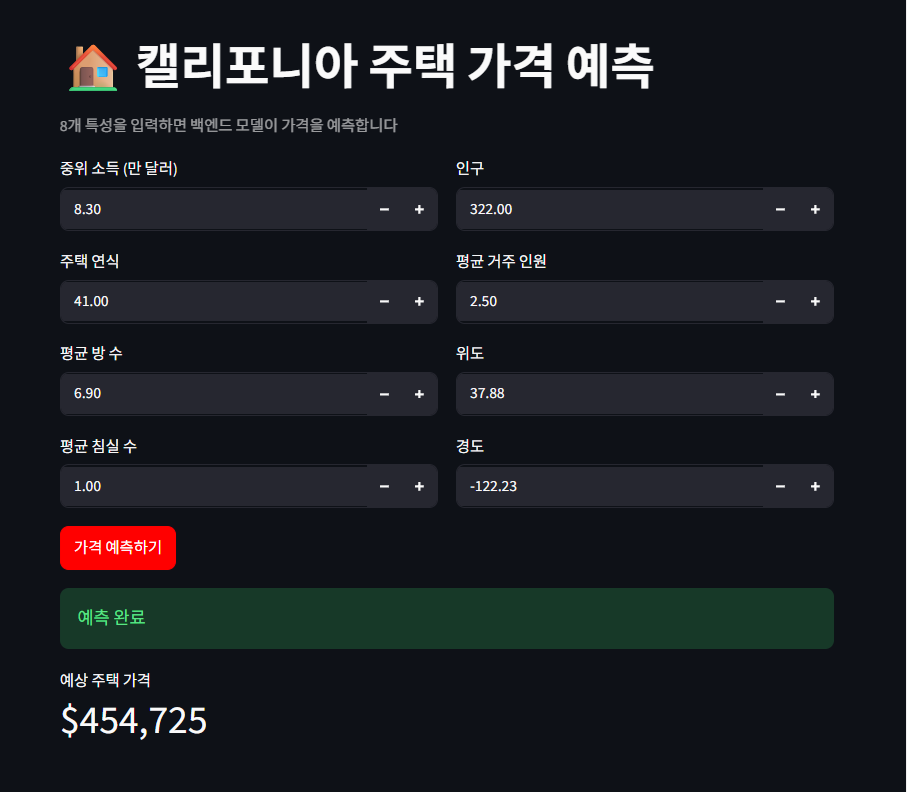

### 파일 구조 

```
model-serving-course/
│
├─ app/  ← 백엔드 (서버 쪽). 여기 12개가 두 무리로 나뉨
│   │
│   │  ━━━ 🟢 오늘 만든 것 (집값 서비스) — 이게 진짜 결과물 ━━━
│   ├─ housing_api.py       ★ 서버 본체. 나머지를 다 불러모으는 지휘소
│   ├─ housing_model.py       추론기 (모델 정의 + 예측 로직)
│   ├─ housing_schemas.py     입출력 계약 (입력 검증 규칙)
│   ├─ logger_config.py       로그 도구      ┐
│   ├─ middleware.py          요청 자동 로깅  ├ Day3 부품 3종
│   ├─ error_handlers.py      에러 그물망     ┘
│   │
│   │  ━━━ ⚪ 옛날 것 (Day1~2 MNIST 연습)  ━━━
│   ├─ main.py              MNIST 최종 서버 
│   ├─ main_basic.py        Day2 최소 서버 연습
│   ├─ main_params.py       Day2 파라미터 연습 
│   ├─ model_utils.py       MNIST 추론기
│   ├─ schemas.py           MNIST 계약 
│   └─ test_repro.py        재현용 테스트 잔재
│
├─ models/  ← 저장된 모델
│   ├─ 🟢 housing_model.pth + housing_preprocessing.json   집값예측
│   └─ ⚪ model.pth / .pt / .onnx                          Day1 MNIST
│
├─ app_housing.py  🟢 프론트 (Streamlit 화면) 
│
└─ notebooks/day1_serialization.ipynb  작업 노트북
```




### 작동 방식 
```
[사람] 브라우저에서 숫자 입력 + 버튼
   ↓
app_housing.py (프론트) ── requests.post ──→ housing_api.py (백엔드 지휘소)
                                                  │ 1. housing_schemas 로 입력 검사
                                                  │ 2. housing_model 로 추론
                                                  │ 3. logger/middleware/error 가 거들기
                                                  ↓
                                            예측 가격 JSON 응답
   ↑                                              │
app_housing.py 가 화면에 $454,725 표시   ←──────────┘
```
전처리 파라미터(mean/std)를 모델과 함께 저장하는 이유: 배포 환경의 새 입력을 학습 때와 같은 스케일로 정규화해야 예측이 맞기 때문. 모델 가중치만으론 부족하다.

스키마 범위 검증(Latitude le=42 등): 캘리포니아 데이터로만 학습했으므로, 범위 밖 입력은 모델에 닿기 전에 막는다.

프론트 입력 필드명 = 백엔드 스키마 필드명이 글자까지 일치해야 하는 이유: 두 서버가 HTTP 계약으로 연결되므로, 이름이 어긋나면 422로 거절된다.

### 회고 

캘리포니아 주택가격 예측 서비스를 완성했다. 
구조는 Streamlit(프론트) → FastAPI(백엔드) → PyTorch 모델
크게 3분류로 나눌수 있었고 브라우저에 집 정보 8개를 입력하면 백앤드 모델이 가격을 예측해서 화면에 띄운다. 

프론트와 백엔드는 분리된 코드를 넘어서 완전히 분리된 시스템이었다는게 가장 큰 깨달음이었다. 
그냥 단순히 파일이 나뉜게 아니라 물리적으로 다른 서버를 쓰면서 그 사이를 HTTP requests.post가 이어준다. 
그래서 노트북에서 할떄는 한 노트북에서 두개의 서버를 구동해야하니 충돌이 잦았다. 
또한 보통 화면과 엔진같은 경우에는 플랫폼에서는 이걸 하나로 자동으로 연결되기 때문에 쓸때는 모르지만 이걸 실제로 연결하는 
입력 필드명 = 스키마 필드명 으로 맞춰주는 일이 어려웠다. 

그 중에서도 백엔드, 프론트앤드 이것들의 코드를 따라치면서도 지금 뭘 만드는 중인지 직관이 잘 안잡히는게 고역이었다. 
순서대로 코드를 따라 짜면서도 어떤 작업을 하는지 잘 와닿지가 않았는데, 크게 한번 정도 이렇게 과정을 거치고 나니 그래도 약간은 감이 잡힐것 같은 기분이 들기도 한다. 물론 익숙해지려면 아직도 한참이 걸릴것 같다. 

이번 과정이 모두 연결된거라고 착각해서 1~5일차의 기록이 한 노트북에 들ㅇ어갔는데 
사실 집값예측이랑 MNIST는 완전히 다른 거라 사실 별개로 작업을 해도 좋았을거라는 것.. 
